# ICU Early Warning Prediction System  
## Week 1 — Day 1: Dataset Exploration

This notebook is the first exploration step of the ICU & Early Warning Prediction System project.

The goal of this notebook is to:
- Load one ICU patient file
- Understand the dataset structure
- Inspect medical features
- Check missing values
- Identify the prediction target: `SepsisLabel`

## Phase 1 — Import Required Libraries

In this phase, we import the basic Python libraries needed for data loading and exploration.

In [1]:
# Import pandas for reading and analyzing tabular medical data
import pandas as pd

# Import matplotlib for future visualizations
import matplotlib.pyplot as plt

# Import Path for folder management
from pathlib import Path

# Create figures output folder for Day 1
figures_path = Path("../figures/day1")
figures_path.mkdir(parents=True, exist_ok=True)

In [2]:
from pathlib import Path

figures_path = Path("../figures/day1")
figures_path.mkdir(parents=True, exist_ok=True)

## Phase 2 — Load One Patient File

Each `.psv` file represents one ICU patient.

Each row represents one hour of ICU monitoring.

The file is separated using the `|` symbol, so we use `sep="|"`.

In [3]:
# Define the path to one patient file
file_path = "../data/raw/p000001.psv"

# Load the patient file into a pandas DataFrame
df = pd.read_csv(file_path, sep="|")

# Display the first 5 rows
df.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


## Phase 3 — Inspect Dataset Size and Columns

In this phase, we check the number of rows and columns and display all available medical features.

In [4]:
# Display dataset shape: number of rows and columns
print("Dataset shape:", df.shape)

# Display all column names
print("Columns:")
print(df.columns.tolist())

Dataset shape: (54, 41)
Columns:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']


### Interpretation

The dataset contains:
- 54 ICU hourly records
- 41 medical features

Each row represents one hour of ICU monitoring for a single patient.

The dataset includes:
- vital signs,
- laboratory values,
- demographic information,
- and the target variable `SepsisLabel`.

## Phase 4 — Understand General Dataset Information

This phase shows the data types, number of non-null values, and general structure of the patient record.

In [5]:
# Show dataset information including data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HR                49 non-null     float64
 1   O2Sat             44 non-null     float64
 2   Temp              10 non-null     float64
 3   SBP               42 non-null     float64
 4   MAP               42 non-null     float64
 5   DBP               0 non-null      float64
 6   Resp              50 non-null     float64
 7   EtCO2             0 non-null      float64
 8   BaseExcess        7 non-null      float64
 9   HCO3              2 non-null      float64
 10  FiO2              4 non-null      float64
 11  pH                7 non-null      float64
 12  PaCO2             6 non-null      float64
 13  SaO2              4 non-null      float64
 14  AST               1 non-null      float64
 15  BUN               2 non-null      float64
 16  Alkalinephos      1 non-null      float64
 17 

### Interpretation

The dataset contains many missing values, which is common in ICU medical data.

Some features such as:
- `HR`,
- `O2Sat`,
- and `Resp`

are recorded frequently.

Other laboratory features are rarely measured and therefore contain many missing values.

This indicates that preprocessing and missing value handling will be a major challenge in this project.

## Phase 5 — Basic Statistical Summary

This phase gives a first statistical overview of the patient’s vital signs and laboratory values.

In [6]:
# Generate descriptive statistics for numeric columns
df.describe()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
count,49.000000,44.000000,10.000000,42.000000,42.000000,0.0,50.000000,0.0,7.000000,2.00000,...,2.000000,0.0,2.000000,5.400000e+01,54.0,0.0,0.0,5.400000e+01,54.000000,54.0
mean,101.571429,91.477273,36.778000,126.809524,87.261905,NaN,24.820000,NaN,20.714286,46.50000,...,10.200000,NaN,327.500000,8.314000e+01,0.0,NaN,NaN,-3.000000e-02,27.500000,0.0
std,9.594378,3.460667,0.421078,22.422482,21.270465,NaN,4.106689,NaN,2.138090,2.12132,...,6.363961,NaN,14.849242,2.868859e-14,0.0,NaN,NaN,3.502025e-18,15.732133,0.0
min,76.000000,85.000000,36.110000,78.000000,44.000000,NaN,17.000000,NaN,18.000000,45.00000,...,5.700000,NaN,317.000000,8.314000e+01,0.0,NaN,NaN,-3.000000e-02,1.000000,0.0
25%,98.000000,89.000000,36.515000,111.875000,76.330000,NaN,22.000000,NaN,19.500000,45.75000,...,7.950000,NaN,322.250000,8.314000e+01,0.0,NaN,NaN,-3.000000e-02,14.250000,0.0
50%,104.000000,91.000000,36.725000,128.000000,87.915000,NaN,25.000000,NaN,20.000000,46.50000,...,10.200000,NaN,327.500000,8.314000e+01,0.0,NaN,NaN,-3.000000e-02,27.500000,0.0
75%,108.000000,93.000000,37.110000,138.750000,96.670000,NaN,28.750000,NaN,22.000000,47.25000,...,12.450000,NaN,332.750000,8.314000e+01,0.0,NaN,NaN,-3.000000e-02,40.750000,0.0
max,117.000000,100.000000,37.440000,181.000000,141.330000,NaN,32.000000,NaN,24.000000,48.00000,...,14.700000,NaN,338.000000,8.314000e+01,0.0,NaN,NaN,-3.000000e-02,54.000000,0.0


### Interpretation

Basic statistics show that:
- the patient’s average heart rate is elevated,
- oxygen saturation varies over time,
- and several laboratory measurements are sparsely available.

The dataset demonstrates the complexity of real-world ICU monitoring systems.

## Phase 6 — Missing Values Analysis

ICU datasets often contain many missing values because not all measurements are taken every hour.

In this phase, we calculate how many values are missing in each column.

In [7]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Calculate missing percentage for each column
missing_percentage = (missing_values / len(df)) * 100

# Combine results into one clean table
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

# Sort columns by highest missing percentage
missing_table.sort_values(by="Missing Percentage (%)", ascending=False)

,Missing Values,Missing Percentage (%)
EtCO2,54,100.000000
DBP,54,100.000000
TroponinI,54,100.000000
Fibrinogen,54,100.000000
Unit1,54,100.000000
Unit2,54,100.000000
PTT,54,100.000000
Bilirubin_direct,54,100.000000
Lactate,54,100.000000
Bilirubin_total,53,98.148148


### Interpretation

Several medical features contain extremely high missing percentages.

Examples:
- `EtCO2`
- `TroponinI`
- `Fibrinogen`

Some features are completely missing for this patient.

This highlights the importance of:
- imputation strategies,
- feature selection,
- and robust preprocessing pipelines.

## Phase 7 — Target Variable Analysis

The target variable is `SepsisLabel`.

- `0` means the patient is not labeled as septic at that hour.
- `1` means the patient is labeled as septic at that hour.

This phase checks whether this patient developed sepsis during the ICU stay.

In [8]:
# Count how many rows are labeled as septic or non-septic
df["SepsisLabel"].value_counts()

SepsisLabel
0    54
Name: count, dtype: int64

### Interpretation

This patient never developed sepsis during the ICU stay.

All values of `SepsisLabel` are equal to `0`.

This means the patient belongs to the non-septic class.

## Phase 8 — First Time-Series Visualization

Since this is ICU monitoring data, the order of rows matters.

Here, we plot heart rate over time to observe how the patient’s condition changes hour by hour.

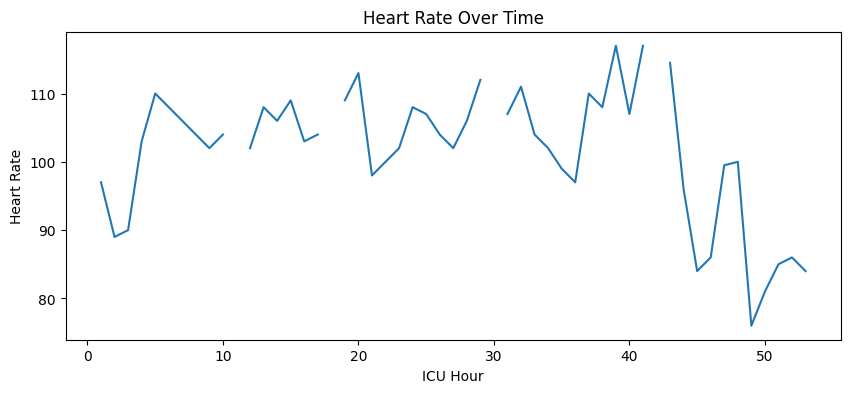

In [9]:
# Plot Heart Rate over ICU hours
plt.figure(figsize=(10, 4))
plt.plot(df["HR"])

# Add chart title and labels
plt.title("Heart Rate Over Time")
plt.xlabel("ICU Hour")
plt.ylabel("Heart Rate")

# Save figure
plt.savefig(
    figures_path / "day1_heart_rate_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

### Interpretation

The heart rate changes over time and demonstrates the temporal nature of ICU monitoring data.

This confirms that the project is fundamentally a time-series prediction problem rather than a static classification problem.

## Phase 9 — Day 1 Observations

Initial observations from this notebook:

- Each patient is stored in a separate `.psv` file.
- Each row represents one ICU hour.
- The dataset contains vital signs, lab values, demographic data, and the sepsis label.
- Many clinical features contain missing values.
- `SepsisLabel` is the main prediction target.
- This project is a time-series medical AI problem, not a simple static classification problem.